# Multiple regression on different data: penguin body mass

*Part 2 · Lesson 19 · another dataset  ·  data: Palmer Penguins*

*↩ A companion to [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb).*

**↩ Back:** [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](19-multiple-regression~the-code.ipynb)

The core lesson fit house prices to **area, quality, and year** on thousands of homes, and watched
area's value-per-square-foot get cut roughly in **half** once quality entered the model. The lesson
was: each coefficient is an **adjusted** effect — what *this* predictor is worth **holding the others
fixed** — and that adjustment is the regression face of *confounding*.

Here we tell the **same story on a smaller, more vivid dataset** where you can almost see the adjustment
happen with the naked eye: **342 penguins** measured at Palmer Station, Antarctica. We'll predict each
penguin's **body mass** (in grams) from its **flipper length**, then add the penguin's **species** — and
watch the flipper slope fall from about **49.7** grams-per-millimetre to about **40.7**. The reason is a
single, transparent confounder: **Gentoo penguins** have *both* longer flippers *and* more mass, so the
simple model was quietly crediting flipper length for a difference that is really "Gentoos are bigger."
Where the housing example was big and a touch abstract, this one is small enough to plot every point and
literally *see* the three fitted lines snap into place. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
sl.use_course_style()

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
pen = sl.load_csv('penguins.csv', url=PENGUINS_URL)

# Keep only the rows that have the three things this lesson needs.
pen = pen.dropna(subset=['body_mass_g', 'flipper_length_mm', 'species'])

print(f'{len(pen)} penguins (Palmer Station, Antarctica)')
print('Three species: ' + ', '.join(pen['species'].unique()))
print(pen['species'].value_counts().to_string())
pen[['species', 'flipper_length_mm', 'body_mass_g', 'sex']].head()

342 penguins (Palmer Station, Antarctica)
Three species: Adelie, Gentoo, Chinstrap
species
Adelie       151
Gentoo       123
Chinstrap     68


,species,flipper_length_mm,body_mass_g,sex
0,Adelie,181.0,3750.0,male
1,Adelie,186.0,3800.0,female
2,Adelie,195.0,3250.0,female
4,Adelie,193.0,3450.0,female
5,Adelie,190.0,3650.0,male


## 1) The same machinery, a new question

In the *Relationships* lesson we fit a **simple** regression — one predictor:

$$\hat{y} = b_0 + b_1 x.$$

**Multiple regression** just adds more $x$'s, each with its own slope:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots$$

- **The math:** instead of the best *line* through a 2-D cloud, we fit the best *flat sheet* through a
  higher-dimensional cloud — still by **least squares**, still minimizing $\sum (y_i - \hat{y}_i)^2$.
- **The meaning:** each $b_j$ is the slope **in its own direction** — how much $\hat{y}$ moves when $x_j$
  rises by one unit *and the other predictors stay put*.
- **The interpretation:** that phrase **"holding the others constant"** is the whole game. It lets us
  ask "what is an extra millimetre of flipper worth, *comparing penguins of the same species*?" — a
  fairer question than the simple model can answer.

We'll use **`smf.ols`** from statsmodels (`ols` = ordinary least squares). You write the model as a
**formula** string, `'y ~ x1 + x2'`, and it does the algebra. (No money in sight here, so there's
nothing to mistake for currency — everything is in **grams** and **millimetres**.)

## 2) The baseline: mass from flipper length alone

First the familiar one-predictor fit, so we have a number to watch. Bigger penguins have bigger
everything, so we expect a healthy positive slope.

In [2]:
model_flip = smf.ols('body_mass_g ~ flipper_length_mm', data=pen).fit()

b0 = model_flip.params['Intercept']
b1 = model_flip.params['flipper_length_mm']
print(f'body_mass_g = {b0:,.0f} + {b1:.2f} * flipper_length_mm')
print(f'\nSimple-model slope on flipper = {b1:.2f} grams per extra millimetre of flipper.')
print(f'R-squared = {model_flip.rsquared:.3f}  ->  flipper length alone explains '
      f'{model_flip.rsquared*100:.0f}% of the variation in body mass.')

body_mass_g = -5,781 + 49.69 * flipper_length_mm

Simple-model slope on flipper = 49.69 grams per extra millimetre of flipper.
R-squared = 0.759  ->  flipper length alone explains 76% of the variation in body mass.


So in a one-predictor world, **an extra millimetre of flipper is "worth" about 49.7 grams.** Hold onto
that number — it's about to change.

## 3) Add species — and watch the flipper coefficient change

Now we let the model *also* see each penguin's **species**. Species is a **category**, not a number, so
we wrap it in `C(...)` — statsmodels reads that as "treat this as categorical" and builds the **dummy
variables** for us (more on those in section 5). We just add `+ C(species)` to the formula.

In [3]:
model_fs = smf.ols('body_mass_g ~ flipper_length_mm + C(species)', data=pen).fit()

print('Slope on FLIPPER LENGTH:')
print(f'   alone:               {model_flip.params["flipper_length_mm"]:7.2f} grams / mm')
print(f'   holding species:     {model_fs.params["flipper_length_mm"]:7.2f} grams / mm   <- DROPPED ~9 g/mm')
print()
print(f'R-squared rose from {model_flip.rsquared:.3f} to {model_fs.rsquared:.3f}.')

Slope on FLIPPER LENGTH:
   alone:                 49.69 grams / mm
   holding species:       40.71 grams / mm   <- DROPPED ~9 g/mm

R-squared rose from 0.759 to 0.783.


### Why did flipper's value fall from ~49.7 to ~40.7 grams?

This is **confounding** — the same lesson as *correlation is not causation* from the descriptive
*Relationships* lesson, now living inside a regression. And here it has a single, nameable culprit:
**Gentoo penguins.**

Gentoos have **both** the longest flippers **and** the most mass. So in the simple model, the flipper
slope was secretly *paid twice*: once for flipper length itself, and once for the **"Gentoo-ness" that
rides along with a long flipper**. The simple slope of 49.7 was really "flipper length **plus** the
species difference that comes with it."

When we put `species` in the model, we let it claim its own share of the credit. What's left for
`flipper_length_mm` is the value of an extra millimetre **among penguins of the same species** — about
**40.7 grams**. That is the *adjusted* effect: the honest answer to "what does a longer flipper add,
holding species fixed?" Let's confirm the two predictors really do travel together.

In [4]:
print('Average flipper length and body mass, by species:')
by_species = pen.groupby('species')[['flipper_length_mm', 'body_mass_g']].mean()
print(by_species.to_string(float_format=lambda v: f'{v:,.0f}'))
print('\nGentoos sit at the top of BOTH columns: longest flippers AND heaviest bodies.')
print('That double-membership is exactly what makes species a confounder of the flipper effect.')

Average flipper length and body mass, by species:
           flipper_length_mm  body_mass_g
species                                  
Adelie                   190        3,701
Chinstrap                196        3,733
Gentoo                   217        5,076

Gentoos sit at the top of BOTH columns: longest flippers AND heaviest bodies.
That double-membership is exactly what makes species a confounder of the flipper effect.


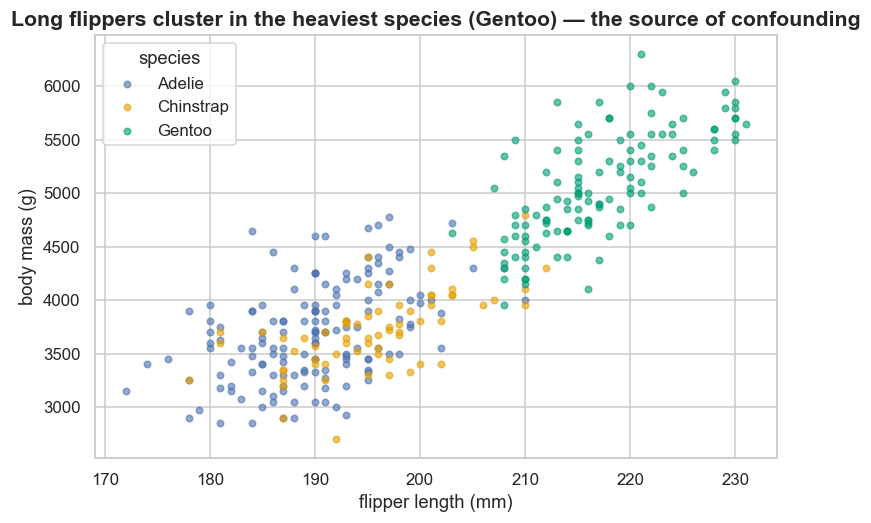

In [5]:
# Picture the confounder: longer flippers travel with the heaviest species (Gentoo).
species_colors = {'Adelie': '#4c72b0', 'Chinstrap': '#E69F00', 'Gentoo': '#009E73'}
fig, ax = plt.subplots()
for sp, color in species_colors.items():
    sub = pen[pen['species'] == sp]
    ax.scatter(sub['flipper_length_mm'], sub['body_mass_g'], s=18, alpha=0.6,
               color=color, label=sp)
ax.set_xlabel('flipper length (mm)'); ax.set_ylabel('body mass (g)')
ax.set_title('Long flippers cluster in the heaviest species (Gentoo) — the source of confounding')
ax.legend(title='species'); plt.show()

Notice how the green **Gentoo** cloud sits up and to the right — long flippers *and* heavy bodies. If you
squint past the colors and fit **one** line to the whole blob, it tilts up steeply (slope ~49.7) partly
because it has to climb from the Adelie/Chinstrap corner up to the Gentoo corner. Some of that climb is
"flipper length," but some of it is just "these are Gentoos." The next section separates the two.

## 4) Seeing the adjustment: three parallel fitted lines

Here is the picture that makes "holding species constant" click. Our model
`body_mass_g ~ flipper_length_mm + C(species)` gives every species the **same slope** (one common
flipper effect, 40.7 g/mm) but its **own intercept** (each species starts at a different mass). On a
chart that is **three parallel lines** — and the *slope of those parallel lines* is the adjusted flipper
effect, visibly gentler than the single steep line through the whole cloud.

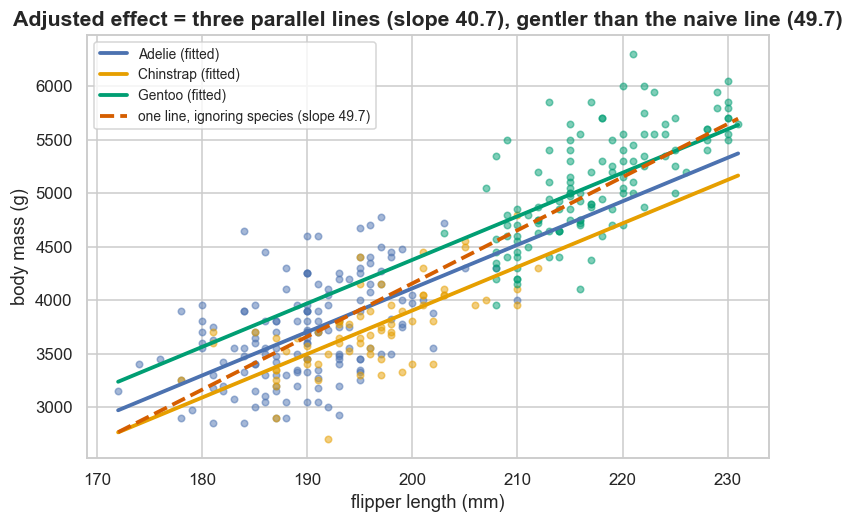

In [6]:
fig, ax = plt.subplots()
flip_grid = np.linspace(pen['flipper_length_mm'].min(), pen['flipper_length_mm'].max(), 50)

for sp, color in species_colors.items():
    sub = pen[pen['species'] == sp]
    ax.scatter(sub['flipper_length_mm'], sub['body_mass_g'], s=18, alpha=0.5, color=color)
    # The fitted line for THIS species: common slope, its own intercept.
    pred = model_fs.predict(pd.DataFrame({'flipper_length_mm': flip_grid, 'species': sp}))
    ax.plot(flip_grid, pred, color=color, lw=2.5, label=f'{sp} (fitted)')

# The single naive line through everything, for contrast.
naive = model_flip.predict(pd.DataFrame({'flipper_length_mm': flip_grid}))
ax.plot(flip_grid, naive, color='#D55E00', lw=2.5, ls='--',
        label='one line, ignoring species (slope 49.7)')

ax.set_xlabel('flipper length (mm)'); ax.set_ylabel('body mass (g)')
ax.set_title('Adjusted effect = three parallel lines (slope 40.7), gentler than the naive line (49.7)')
ax.legend(fontsize=9); plt.show()

The three solid lines are **parallel** — that's the dummy-variable model in action: one shared slope,
three different starting heights. Their slope (40.7) is *flatter* than the red dashed "ignore species"
line (49.7), because the steep red line was partly tracking the jump from the lighter species up to the
heavy Gentoos. Once each species gets its own line, the flipper effect is measured **within** species,
and it's gentler. **That gap between the dashed line and the parallel lines is the adjustment** — the
same thing as house area's slope getting halved when quality entered the core lesson.

## 5) Read the regression table — and the dummy variables in it

statsmodels prints the whole story with `.summary()`. It looks busy; we only need a few cells of it.

In [7]:
print(model_fs.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     405.7
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          1.25e-111
Time:                        11:11:35   Log-Likelihood:                -2510.8
No. Observations:                 342   AIC:                             5030.
Df Residuals:                     338   BIC:                             5045.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4

### A guided tour of the numbers that matter

Focus on the **coefficient table** (the middle block) and the fit numbers up top:

- **`flipper_length_mm`** ≈ **40.7** grams per extra mm, *holding species fixed* — the adjusted effect,
  the common slope of those three parallel lines.
- **`C(species)[T.Chinstrap]`** and **`C(species)[T.Gentoo]`** are the **dummy variables**. A category
  can't enter a regression as text, so each species becomes a 0/1 indicator column. One species —
  **Adelie**, the alphabetical first — is held out as the **baseline** and folded into the `Intercept`.
  Each dummy's coefficient is then "how much heavier (or lighter) than an Adelie *of the same flipper
  length*":
  - `C(species)[T.Chinstrap]` ≈ **-207 g** — a Chinstrap is a touch *lighter* than an Adelie with the
    same flipper length.
  - `C(species)[T.Gentoo]` ≈ **+267 g** — a Gentoo is heavier than an Adelie of the same flipper length.
  These two numbers are exactly the vertical gaps between the parallel lines in the chart above.
- **`std err`**, **`t`**, **`P>|t|`** — the standard error of each slope, a t-statistic, and its
  **p-value** for the null "this coefficient is really 0." Tiny p-values say a predictor adds something
  **beyond** the others. (The *Correlation & regression: inference* lesson builds this idea in full.)
- **`R-squared`** and **`Adj. R-squared`** (top right) — how much of body-mass variation the model
  explains. That second one is the subject of the next section, and it's the one to trust.

## 6) $R^2$ versus **adjusted** $R^2$ — why the asterisk matters

Plain $R^2$ has a sneaky flaw: **it can never go down when you add a predictor — even a useless one.**
Any new column, however irrelevant, can be twisted to soak up a sliver of leftover variation by chance.
So "higher $R^2$" is *not* proof that a bigger model is better.

**Adjusted $R^2$** fixes this by charging a **penalty for each predictor**:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{\,n - k - 1\,},$$

where $n$ is the number of penguins and $k$ is the number of predictors. Add a predictor that pulls its
weight and adjusted $R^2$ rises; add **junk** and it **falls**, because the penalty outweighs the fluke
gain. Let's prove it: first add a column of **pure random noise** (adjusted $R^2$ should *drop*), then add
a genuinely useful predictor — **sex** (it should *rise*).

In [8]:
rng = np.random.default_rng(7)   # change this seed — the verdict won't change
pen_noise = pen.copy()
pen_noise['random_noise'] = rng.normal(size=len(pen_noise))   # meaningless made-up column
model_junk = smf.ols('body_mass_g ~ flipper_length_mm + C(species) + random_noise',
                     data=pen_noise).fit()

print(f'{"model":<34}{"plain R^2":>12}{"adjusted R^2":>15}')
print(f'{"flipper + species":<34}{model_fs.rsquared:>12.5f}{model_fs.rsquared_adj:>15.5f}')
print(f'{"  + random noise (junk)":<34}{model_junk.rsquared:>12.5f}{model_junk.rsquared_adj:>15.5f}')
print('\nPlain R^2 ticked UP (it always does). Adjusted R^2 went DOWN:')
print('the penalty saw through the useless column. Trust the adjusted number.')

model                                plain R^2   adjusted R^2
flipper + species                      0.78265        0.78072
  + random noise (junk)                0.78281        0.78023

Plain R^2 ticked UP (it always does). Adjusted R^2 went DOWN:
the penalty saw through the useless column. Trust the adjusted number.


In [9]:
# Now a predictor that genuinely earns its place: the penguin's sex.
pen_sex = pen.dropna(subset=['sex'])                       # a few penguins are missing sex
model_fss = smf.ols('body_mass_g ~ flipper_length_mm + C(species) + C(sex)', data=pen_sex).fit()

print(f'{"model":<34}{"plain R^2":>12}{"adjusted R^2":>15}')
print(f'{"flipper + species":<34}{model_fs.rsquared:>12.5f}{model_fs.rsquared_adj:>15.5f}')
print(f'{"  + sex (a real predictor)":<34}{model_fss.rsquared:>12.5f}{model_fss.rsquared_adj:>15.5f}')
print()
print(f'Adjusted R^2 ROSE: sex pulls its weight. And notice the flipper slope adjusts AGAIN:')
print(f'   flipper + species:        {model_fs.params["flipper_length_mm"]:6.2f} g/mm')
print(f'   flipper + species + sex:  {model_fss.params["flipper_length_mm"]:6.2f} g/mm   '
      f'(males are heavier, so sex absorbs more of the credit)')
print(f'   sex coefficient (male vs female): {model_fss.params["C(sex)[T.male]"]:+.0f} g, holding the rest fixed.')

model                                plain R^2   adjusted R^2
flipper + species                      0.78265        0.78072
  + sex (a real predictor)             0.86689        0.86527

Adjusted R^2 ROSE: sex pulls its weight. And notice the flipper slope adjusts AGAIN:
   flipper + species:         40.71 g/mm
   flipper + species + sex:   20.02 g/mm   (males are heavier, so sex absorbs more of the credit)
   sex coefficient (male vs female): +530 g, holding the rest fixed.


**Takeaway:** when you compare models with different numbers of predictors, compare **adjusted $R^2$**,
not plain $R^2$. Plain $R^2$ rewards clutter; adjusted $R^2$ rewards predictors that genuinely help —
and just as in the housing lesson, every time a *real* new predictor enters (species, then sex), the
flipper coefficient **re-adjusts** to mean "per mm, holding *everything else* fixed."

## 7) Two cautions before you read too much into a fit

Multiple regression is powerful, which makes it easy to over-claim. Keep two warnings in mind:

1. **It's still not causation.** This is **observational** data — nobody assigned penguins their species
   or sex. "Holding species constant, each mm of flipper adds ~40.7 g" is an *association among
   comparable penguins*, not a promise that *stretching* a flipper would add mass. Earning the word
   *"causes"* needs an experiment or much heavier machinery (the *Where data comes from* lesson explains why).
2. **Extrapolation still bites.** The model learned from flippers of about 172–231 mm. Predicting the
   mass of a penguin with a 300 mm flipper is pure fantasy — the fitted sheet knows nothing outside the
   cloud it was fit to.

## Now you try

Predict first, then change a number and re-run:

1. **Reverse the build-up.** Fit `body_mass_g ~ C(species)` *alone* in a new cell, then compare a
   species coefficient to its value in `model_fs` (`flipper_length_mm + C(species)`). Does the species
   gap shrink once flipper length is controlled for? What does that tell you about how flipper length and
   species share the credit?

2. **Add bill length.** The dataset has `bill_length_mm`. Try
   `smf.ols('body_mass_g ~ flipper_length_mm + C(species) + bill_length_mm', data=pen.dropna(subset=['bill_length_mm'])).fit().summary()`.
   Does **adjusted** $R^2$ go up (bill length earns its place) or barely move (it's redundant with what
   flipper and species already say)?

3. **Change the baseline species.** statsmodels makes Adelie the baseline because it's first
   alphabetically. Force Gentoo to be the baseline with
   `C(species, Treatment(reference="Gentoo"))` in the formula. Which coefficients flip sign, and why does
   the *flipper slope* stay exactly the same?

4. **Change the noise seed.** In section 6 swap `np.random.default_rng(7)` for any other number. Does
   adjusted $R^2$ still fall when you add the random-noise column? (It should — the penalty doesn't care
   which random numbers you feed it.)

## What you learned

- **Multiple regression** fits several predictors at once: $\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots$,
  still by least squares — here, penguin **body mass** from **flipper length** and **species**.
- Each coefficient is an **adjusted** effect — the change in $y$ per unit of *that* predictor **holding
  the others constant**. The flipper slope fell from **49.7** to **40.7** g/mm once species entered.
- That change is **confounding**: Gentoos have both longer flippers *and* more mass, so the simple model
  was crediting flipper length for a species difference. Holding species fixed isolates the *within*-species
  flipper effect — the same trap that halved house area's slope in the core lesson, on data small enough
  to *see* as three parallel fitted lines.
- A **categorical** predictor enters as **dummy (0/1) variables** with one level held out as the
  baseline (Adelie); each dummy's coefficient is that level's gap from the baseline — the vertical spacing
  between the parallel lines.
- Compare models by **adjusted $R^2$**, which **penalizes useless predictors** (random noise made it
  *fall*) and rewards real ones (adding sex made it *rise*), unlike plain $R^2$, which never goes down.
- Stay humble: an observational fit shows **association, not causation**, and trusts nothing outside the
  range of the data it learned from.

---

**↩ Back to the lesson:** [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](19-multiple-regression~the-code.ipynb)